Rubtcova Vera  
Algorithms Task 2

## Goal  
The use of direct methods (one-dimensional methods of exhaustive search,
dichotomy, golden section search; multidimensional methods of exhaustive search,
Gauss (coordinate descent), Nelder-Mead) in the tasks of unconstrained nonlinear
optimization

In [141]:
import math
import pandas as pd
import random

#### Theory: Exhaustive search - Algorithm
1. Consider points $x_k \in [a, b]$ of the form $x_k = a + k \frac{b-a}{n}$, where $k=0, \dots, n$, and the number $n$ is chosen such that $\frac{b-a}{n} \leqslant \epsilon$.
2. Calculate the values ​​$f(x_k)$ for all $k \in \{0, \dots, n\}$ and find $\hat{x}$ such that $f(\hat{x}) = \min f(x_k)$.
3. Then $|\hat{x} - x^*| \leqslant \epsilon$, meaning that $\hat{x}$ is an approximation of $x^*$.

#### Task 1  
Use the one-dimensional methods of exhaustive search, dichotomy and golden
section search to find an approximate (with precision 𝜀 = 0.001) solution:	𝑓(𝑥) → 𝑚𝑖𝑛 for the following functions and domains:
1. 𝑓(𝑥) = 𝑥 , 𝑥 ∈ [0,1];
2. 𝑓(𝑥) = |𝑥 −0.2|, 𝑥 ∈ [0,1];
3. 𝑓(𝑥) = 𝑥	𝑠𝑖𝑛 (1/𝑥)
, 𝑥 ∈ [0.01,1].
Calculate the number of 𝑓-calculations and the number of iterations performed in each method and analyze the results. Explain differences (if any) in the results obtained.


In [142]:
x3_fun = lambda x: x**3
abs_fun = lambda x: abs(x - 0.2)
sin_fun = lambda x: x * math.sin(1/x)

In [143]:
def exhaustive_search(f, a, b, eps):
  n = math.ceil((b - a) / eps)
  calcs_cnt = 0

  best_x = a
  best_f = f(a)
  calcs_cnt += 1

  for k in range(1, n + 1):
    x_k = a + k * (b - a) / n
    f_k = f(x_k)
    calcs_cnt += 1
    if f_k < best_f:
      best_f = f_k
      best_x = x_k

  iterations = n + 1
  return best_f, best_x, calcs_cnt, iterations

In [144]:
x3_best_f_es, x3_best_x_es, x3_calcs_cnt_es, x3_iterations_es = exhaustive_search(x3_fun, 0, 1,  0.001)
print(f"f(x) = 𝑥^3 : min(𝑥) = {x3_best_x_es:.3f}, min f(𝑥) = {x3_best_f_es:.3f}, calculations = {x3_calcs_cnt_es}, iterations = {x3_iterations_es}")

abs_best_f_es, abs_best_x_es, abs_calcs_cnt_es, abs_iterations_es = exhaustive_search(abs_fun, 0, 1,  0.001)
print(f"f(x) = |𝑥 − 0.2| : min(𝑥) = {abs_best_x_es:.3f}, min f(𝑥) = {abs_best_f_es:.3f}, calculations = {abs_calcs_cnt_es}, iterations = {abs_iterations_es}")

sin_best_f_es, sin_best_x_es, sin_calcs_cnt_es, sin_iterations_es = exhaustive_search(sin_fun, 0.01, 1,  0.001)
print(f"f(x) = 𝑥 * sin(1/x) : min(𝑥) = {sin_best_x_es:.3f}, min f(𝑥) = {sin_best_f_es:.3f}, calculations = {sin_calcs_cnt_es}, iterations = {sin_iterations_es}")

f(x) = 𝑥^3 : min(𝑥) = 0.000, min f(𝑥) = 0.000, calculations = 1001, iterations = 1001
f(x) = |𝑥 − 0.2| : min(𝑥) = 0.200, min f(𝑥) = 0.000, calculations = 1001, iterations = 1001
f(x) = 𝑥 * sin(1/x) : min(𝑥) = 0.223, min f(𝑥) = -0.217, calculations = 991, iterations = 991


#### Theory: Dichotomy method - algorithm

1. Calculate  
$$x_1 = \frac{a_0 + b_0 - \delta}{2}, \quad x_2 = \frac{a_0 + b_0 + \delta}{2}, \quad 0 < \delta < \epsilon,$$  
then $f(x_1)$ and $f(x_2)$.

2. Reduce the indeterminacy segment down to the segment $[a_1, b_1]$:  
if $f(x_1) \leqslant f(x_2)$, then $a_1 = a_0$ and $b_1 = x_2$;  
$a_1 = x_1$ and $b_1 = b_0$, otherwise.

3. Furthermore, by analogous formulas find $x_1$ and $x_2 \in [a_1, b_1]$.  
Repeat the reducing procedure down to a segment $[a_2, b_2]$, etc.

4. The search is stopped if at the current $k$-th iteration it holds that  
$|a_k - b_k| < \epsilon$; $x^* \in [a_k, b_k]$.

In [145]:
def dichotomy(f, a, b, eps):
  calcs_cnt = 0
  iterations = 0

  while b - a >= eps:
    x1 = (a + b - (eps/2)) / 2
    x2 = (a + b + (eps/2)) / 2

    f_x1 = f(x1)
    f_x2 = f(x2)
    calcs_cnt += 2

    if f_x1 <= f_x2:
      b = x2
    else:
      a = x1

    iterations +=1

  best_x = (a + b) / 2
  best_f = f(best_x)
  calcs_cnt += 1
  return best_f, best_x, calcs_cnt, iterations

In [146]:
x3_best_f_d, x3_best_x_d, x3_calcs_cnt_d, x3_iterations_d = dichotomy(x3_fun, 0, 1,  0.001)
print(f"f(x) = 𝑥^3 : min(𝑥) = {x3_best_x_d:.3f}, min f(𝑥) = {x3_best_f_d:.3f}, calculations = {x3_calcs_cnt_d}, iterations = {x3_iterations_d}")

abs_best_f_d, abs_best_x_d, abs_calcs_cnt_d, abs_iterations_d = dichotomy(abs_fun, 0, 1,  0.001)
print(f"f(x) = |𝑥 − 0.2| : min(𝑥) = {abs_best_x_d:.3f}, min f(𝑥) = {abs_best_f_d:.3f}, calculations = {abs_calcs_cnt_d}, iterations = {abs_iterations_d}")

sin_best_f_d, sin_best_x_d, sin_calcs_cnt_d, sin_iterations_d = dichotomy(sin_fun, 0.01, 1,  0.001)
print(f"f(x) = 𝑥 * sin(1/x) : min(𝑥) = {sin_best_x_d:.3f}, min f(𝑥) = {sin_best_f_d:.3f}, calculations = {sin_calcs_cnt_d}, iterations = {sin_iterations_d}")

f(x) = 𝑥^3 : min(𝑥) = 0.000, min f(𝑥) = 0.000, calculations = 23, iterations = 11
f(x) = |𝑥 − 0.2| : min(𝑥) = 0.200, min f(𝑥) = 0.000, calculations = 23, iterations = 11
f(x) = 𝑥 * sin(1/x) : min(𝑥) = 0.223, min f(𝑥) = -0.217, calculations = 23, iterations = 11


#### Theory: Golden section method - algorithm
1. Calculate $x_1 = a_0 + \frac{3-\sqrt{5}}{2}(b_0 - a_0)$, $x_2 = a_0 + \frac{\sqrt{5}-1}{2}(b_0 - a_0)$ (note that $\frac{x_1+x_2}{2} = \frac{a_0+b_0}{2}$),
as well as the values ​​$f(x_1)$ and $f(x_2)$ (in the first iteration, the function values ​​at two points must be calculated).
2. Narrow the interval of uncertainty to the segment $[a_1, b_1]$:
if $f(x_1) \le f(x_2)$, then $a_1 = a_0$, $b_1 = x_2$, $x_2 = x_1$;
otherwise, $a_1 = x_1$, $b_1 = b_0$, $x_1 = x_2$.
3. In subsequent iterations, calculate one point and the corresponding value of $f$:
in the first case, $x_1$ and $f(x_1)$; in the second, $x_2$ and $f(x_2)$.
4. The search terminates if, at the current $k$-th iteration, the condition $|b_k - a_k| < \epsilon$ is met; in this case, $x^* \in [a_k, b_k]$.

In [147]:
def golden_section(f, a, b, eps):
  calcs_cnt = 0
  iterations = 0

  x1 = a + (3 - math.sqrt(5)) / 2 * (b - a)
  x2 = a + (math.sqrt(5) - 1) / 2 * (b - a)

  f_x1 = f(x1)
  f_x2 = f(x2)
  calcs_cnt += 2

  while b - a >= eps:
    if f_x1 <= f_x2:
      b = x2
      x2 = x1
      f_x2 = f_x1
      x1 = a + (3 - math.sqrt(5)) / 2 * (b - a)
      f_x1 = f(x1)
    else:
      a = x1
      x1 = x2
      f_x1 = f_x2
      x2 = a + (math.sqrt(5) - 1) / 2 * (b - a)
      f_x2 = f(x2)

    calcs_cnt +=1
    iterations +=1

  best_x = (a + b) / 2
  best_f = f(best_x)
  calcs_cnt += 1
  return best_f, best_x, calcs_cnt, iterations

In [148]:
x3_best_f_gs, x3_best_x_gs, x3_calcs_cnt_gs, x3_iterations_gs = golden_section(x3_fun, 0, 1,  0.001)
print(f"f(x) = 𝑥^3 : min(𝑥) = {x3_best_x_gs:.3f}, min f(𝑥) = {x3_best_f_gs:.3f}, calculations = {x3_calcs_cnt_gs}, iterations = {x3_iterations_gs}")

abs_best_f_gs, abs_best_x_gs, abs_calcs_cnt_gs, abs_iterations_gs = golden_section(abs_fun, 0, 1,  0.001)
print(f"f(x) = |𝑥 − 0.2| : min(𝑥) = {abs_best_x_gs:.3f}, min f(𝑥) = {abs_best_f_gs:.3f}, calculations = {abs_calcs_cnt_gs}, iterations = {abs_iterations_gs}")

sin_best_f_gs, sin_best_x_gs, sin_calcs_cnt_gs, sin_iterations_gs = golden_section(sin_fun, 0.01, 1,  0.001)
print(f"f(x) = 𝑥 * sin(1/x) : min(𝑥) = {sin_best_x_gs:.3f}, min f(𝑥) = {sin_best_f_gs:.3f}, calculations = {sin_calcs_cnt_gs}, iterations = {sin_iterations_gs}")

f(x) = 𝑥^3 : min(𝑥) = 0.000, min f(𝑥) = 0.000, calculations = 18, iterations = 15
f(x) = |𝑥 − 0.2| : min(𝑥) = 0.200, min f(𝑥) = 0.000, calculations = 18, iterations = 15
f(x) = 𝑥 * sin(1/x) : min(𝑥) = 0.223, min f(𝑥) = -0.217, calculations = 18, iterations = 15


### Task 1 conclusions


In [149]:
results = pd.DataFrame([
    {"Function": "x^3",          "Method": "Exhaustive search", "x*": x3_best_x_es,  "f(x*)": x3_best_f_es,  "f-calculations": x3_calcs_cnt_es,  "Iterations": x3_iterations_es},
    {"Function": "x^3",          "Method": "Dichotomy",         "x*": x3_best_x_d,   "f(x*)": x3_best_f_d,   "f-calculations": x3_calcs_cnt_d,   "Iterations": x3_iterations_d},
    {"Function": "x^3",          "Method": "Golden section",    "x*": x3_best_x_gs,  "f(x*)": x3_best_f_gs,  "f-calculations": x3_calcs_cnt_gs,  "Iterations": x3_iterations_gs},

    {"Function": "|x-0.2|",      "Method": "Exhaustive search", "x*": abs_best_x_es, "f(x*)": abs_best_f_es, "f-calculations": abs_calcs_cnt_es, "Iterations": abs_iterations_es},
    {"Function": "|x-0.2|",      "Method": "Dichotomy",         "x*": abs_best_x_d,  "f(x*)": abs_best_f_d,  "f-calculations": abs_calcs_cnt_d,  "Iterations": abs_iterations_d},
    {"Function": "|x-0.2|",      "Method": "Golden section",    "x*": abs_best_x_gs, "f(x*)": abs_best_f_gs, "f-calculations": abs_calcs_cnt_gs, "Iterations": abs_iterations_gs},

    {"Function": "x*sin(1/x)",   "Method": "Exhaustive search", "x*": sin_best_x_es, "f(x*)": sin_best_f_es, "f-calculations": sin_calcs_cnt_es, "Iterations": sin_iterations_es},
    {"Function": "x*sin(1/x)",   "Method": "Dichotomy",         "x*": sin_best_x_d,  "f(x*)": sin_best_f_d,  "f-calculations": sin_calcs_cnt_d,  "Iterations": sin_iterations_d},
    {"Function": "x*sin(1/x)",   "Method": "Golden section",    "x*": sin_best_x_gs, "f(x*)": sin_best_f_gs, "f-calculations": sin_calcs_cnt_gs, "Iterations": sin_iterations_gs},
])

results

,Function,Method,x*,f(x*),f-calculations,Iterations
0,x^3,Exhaustive search,0.000000,0.000000e+00,1001,1001
1,x^3,Dichotomy,0.000494,1.205674e-10,23,11
2,x^3,Golden section,0.000367,4.925680e-11,18,15
3,|x-0.2|,Exhaustive search,0.200000,0.000000e+00,1001,1001
4,|x-0.2|,Dichotomy,0.200101,1.011963e-04,23,11
5,|x-0.2|,Golden section,0.200073,7.331374e-05,18,15
6,x*sin(1/x),Exhaustive search,0.223000,-2.172246e-01,991,991
7,x*sin(1/x),Dichotomy,0.222596,-2.172335e-01,23,11
8,x*sin(1/x),Golden section,0.222720,-2.172323e-01,18,15


All methods yielded approximately equal minimum function values ​​and minimum x-coordinates.   
However, the number of iterations and calculations varies significantly. The first method—exhaustive search—requires the highest number of both iterations and calculations.  
The dichotomy method requires significantly fewer iterations and calculations across all functions.   
The golden-section method requires fewer calculations but more iterations, as it reduces the search range less drastically at each step.

#### Task 2


Generate random numbers α ∈ (0,1) and β ∈ (0,1). Furthermore, generate the noisy
data {xₖ, yₖ}, where k = 0, …, 100, according to the following rule:

yₖ = α·xₖ + β + δₖ,    xₖ = k/100,

where δₖ ~ N(0,1) are values of a random variable with standard normal distribution.

Approximate the data by the following linear and rational functions:
1. F(x, a, b) = a·x + b (linear approximant),
2. F(x, a, b) = a / (1 + b·x) (rational approximant),

by means of least squares through the numerical minimization (with precision
ε = 0.001) of the following function:

D(a, b) = Σₖ₌₀¹⁰⁰ (F(xₖ, a, b) − yₖ)².

To solve the minimization problem, use the methods of exhaustive search, Gauss and
Nelder-Mead. If necessary, set the initial approximations and other parameters of
the methods. Visualize the data and the approximants obtained in a plot separately
for each type of approximant so that one can compare the results for the numerical
methods used. Analyze the results obtained (in terms of number of iterations,
precision, number of function evaluations, etc.).

In [150]:
def generate_data():
  alpha = random.uniform(0,1)
  beta = random.uniform(0,1)

  xs = []
  ys = []
  for k in range(101):
    x_k = k / 100
    delta_k = random.gauss(0,1)
    y_k = alpha * x_k + beta + delta_k
    xs.append(x_k)
    ys.append(y_k)

  return alpha, beta, xs, ys

In [151]:
alpha, beta, xs, ys = generate_data()
print(f"True alpha = {alpha:.4f},\nTrue beta = {beta:.4f}")

True alpha = 0.1412,
True beta = 0.8005


In [152]:
def D(F, a, b, xs, ys):
  d = 0
  for k in range(101):
    d += (F(xs[k], a, b) - ys[k])**2
  return d

In [153]:
def linear_approximant(x, a, b):
  return a * x + b

def rational_approximant(x, a, b):
  return a / (1 + b * x)

#### Theory: Multidimensional exhaustive - algorithm

Let $f(x): D \to \mathbb{R}$, where $x=(x_1, x_2)$ and $D=[0, 1] \times [0, 1]$.
The goal is to find an approximate solution to the optimization problem
$f(x) \to \min$, $(x, y) \in D$, with an error of $\epsilon > 0$.
If $\hat{x}$ is an approximate solution for $x^*$, then a sufficiently fine grid is chosen
such that, for example, the condition $|\hat{x} - x^*| \le \epsilon$ is satisfied.

In [154]:
def multidimensional_exhaustive(F, xs, ys, a_lo, a_hi, b_lo, b_hi, eps):
  n_a = math.ceil((a_hi - a_lo) / eps)
  n_b = math.ceil((b_hi - b_lo) / eps)
  calcs_cnt = 0

  best_a = a_lo
  best_b = b_lo
  best_d = D(F, a_lo, b_lo, xs, ys)
  calcs_cnt += 1

  for i in range(n_a + 1):
        a = a_lo + i * (a_hi - a_lo) / n_a
        for j in range(n_b + 1):
            b = b_lo + j * (b_hi - b_lo) / n_b
            d = D(F, a, b, xs, ys)
            calcs_cnt += 1
            if d < best_d:
                best_d = d
                best_a, best_b = a, b

  iterations = (n_a + 1) * (n_b + 1)
  return best_a, best_b, best_d, calcs_cnt, iterations

In [155]:
linear_a_me, linear_b_me, linear_d_me, linear_calcs_me, linear_iters_me = multidimensional_exhaustive(linear_approximant, xs, ys, 0, 1, 0, 1, 0.001)
print(f" Linear: a = {linear_a_me:.4f}, b = {linear_b_me:.4f}, D = {linear_d_me:.4f}, calcs = {linear_calcs_me}, iterations = {linear_iters_me}")

rational_a_me, rational_b_me, rational_d_me, rational_calcs_me, rational_iters_me = multidimensional_exhaustive(rational_approximant, xs, ys, 0, 1, 0, 1, 0.001)
print(f" Rational: a = {rational_a_me:.4f}, b = {rational_b_me:.4f}, D = {rational_d_me:.4f}, calcs = {rational_calcs_me}, iterations = {rational_iters_me}")

 Linear: a = 0.4690, b = 0.6950, D = 86.4220, calcs = 1002002, iterations = 1002001
 Rational: a = 0.9300, b = 0.0000, D = 88.3049, calcs = 1002002, iterations = 1002001


#### Theory: Gauss method - algorithm

Let $x^0 = (x_1^0, x_2^0)$ be the initial approximation.

1. In the first iteration, we find the point that minimizes the function $f$ with respect to the first variable while keeping the others fixed—
that is, $x_1^1 = \arg\min_{x_1} f(x_1, x_2^0)$—to obtain the new point $x^1 = (x_1^1, x_2^0)$.
2. Next, using $x^1$, we find the minimum point
by varying only the second variable: we find $x_2^1 = \arg\min_{x_2} f(x_1^1, x_2)$
and the new point $x^2 = (x_1^1, x_2^1)$.
3. We then resume the search with respect to the first variable, and so on.
4. The search terminates when one of the following conditions is met:
$|x_i^{k+1} - x_i^k| \le \epsilon$ ($i=1, 2$) or $|f(x^{k+1}) - f(x^k)| \le \epsilon$.
This method is simple; however, problems may arise if the level lines of the function $f$ are close to the line $x_1 = x_2$. If the initial approximation lies on the line $x_1 = x_2$, the process gets "stuck."

In [156]:
def minimize_a(F, b_fixed, xs, ys, a_lo, a_hi, eps):
    objective = lambda a: D(F, a, b_fixed, xs, ys)
    best_d, best_a, calcs, iters = golden_section(objective, a_lo, a_hi, eps)
    return best_a, best_d, calcs, iters

def minimize_b(F, a_fixed, xs, ys, b_lo, b_hi, eps):
    objective = lambda b: D(F, a_fixed, b, xs, ys)
    best_d, best_b, calcs, iters = golden_section(objective, b_lo, b_hi, eps)
    return best_b, best_d, calcs, iters

In [157]:
def gauss_method(F, xs, ys, a0, b0, a_lo, a_hi, b_lo, b_hi, eps):
  calcs_cnt = 0
  iterations = 0

  a,b = a0,b0

  while True:
    new_a, new_d, calcs_a, iters_a = minimize_a(F, b, xs, ys, a_lo, a_hi, eps)
    calcs_cnt += calcs_a

    new_b, new_d, calcs_b, iters_b = minimize_b(F, new_a, xs, ys, b_lo, b_hi, eps)
    calcs_cnt += calcs_b

    iterations += 1

    if abs(new_a - a) < eps and abs(new_b - b) < eps:
      a, b = new_a, new_b
      break

    a, b = new_a, new_b

  best_d = D(F, a, b, xs, ys)
  calcs_cnt += 1
  return a, b, best_d, calcs_cnt, iterations

In [158]:
linear_a_g, linear_b_g, linear_d_g, linear_calcs_g, linear_iters_g = gauss_method(linear_approximant, xs, ys, 0.5, 0.5, 0, 1, 0, 1, 0.001)
print(f" Linear: a = {linear_a_g:.4f}, b = {linear_b_g:.4f}, D = {linear_d_g:.4f}, calcs = {linear_calcs_g}, iterations = {linear_iters_g}")

rational_a_g, rational_b_g, rational_d_g, rational_calcs_g, rational_iters_g = gauss_method(rational_approximant, xs, ys, 0.5, 0.5, 0, 1, 0, 1, 0.001)
print(f" Rational: a = {rational_a_g:.4f}, b = {rational_b_g:.4f}, D = {rational_d_g:.4f}, calcs = {rational_calcs_g}, iterations = {rational_iters_g}")

 Linear: a = 0.4710, b = 0.6939, D = 86.4221, calcs = 613, iterations = 17
 Rational: a = 0.9296, b = 0.0004, D = 88.3076, calcs = 109, iterations = 3


#### Theory: Nelder-Mead method - algorithm

It uses simplexes in $\mathbb{R}^n$. In our case ($n=2$), they are triangles.

**Parameters:** reflection coefficient $\alpha > 0$ (usually $\alpha = 1$), shrinking coefficient $0 < \beta < 1$ (usually $\beta = 0.5$), expansion coefficient $\gamma > 1$ (usually $\gamma = 2$).

This is a heuristic approach which can stuck in a local minima or converge to a non-stationary point.

**Step 1 (preparation).** Choose three points $x_i = (x_i^{(1)}, x_i^{(2)})$, $i=1,2,3$ for the initial simplex (triangle in our case). Calculate $f_1 = f(x_1)$, $f_2 = f(x_2)$, $f_3 = f(x_3)$.

**Step 2 (sorting).** Choose three points from the simplex vertices: $x_h$ with the largest value of $f_h$, $x_g$ with the second-large value of $f_g$, and $x_l$ with the smallest value of $f_l$. The goal of the forthcoming manipulations is to decrease $f_h$ at least.

**Step 3 (gravity centre).** Find the gravity centre for all points except $x_h$:
$$x_c = \frac{1}{2}\sum_{i \ne h} x_i.$$

**Step 4 (reflection).** Reflect the point $x_h$ with respect to $x_c$ with the coefficient $\alpha$ (for $\alpha=1$ is the central symmetry):
$$x_r = (1+\alpha)x_c - \alpha x_h.$$
Calculate $f_r = f(x_r)$.

**Step 5 (expansion).** Furthermore, check how the function values are decreased:
- If $f_r < f_l$, then the direction is right, we can expand: calculate $x_e = (1-\gamma)x_c + \gamma x_r$, $f_e = f(x_e)$.
  - If $f_e < f_r$, the simplex can be expanded: set $x_h := x_e$ and go to Step 7.
  - If $f_r < f_e$, then we moved too far: set $x_h := x_r$ and go to Step 7.
- If $f_l < f_r < f_g$, then the choice of the new point is good (the new one is better than previous two): set $x_h := x_r$ and go to Step 7.
- If $f_g < f_r < f_h$, then exchange $x_r \Leftrightarrow x_h$ and $f_r \Leftrightarrow f_h$. Go to Step 6.
- If $f_h < f_r$, then go to Step 6.

As a result, $f_l < f_g < f_h < f_r$.

**Step 6 (shrinking).** Calculate $x_s = \beta x_h + (1-\beta) x_c$ and $f_s = f(x_s)$.
- If $f_s < f_h$, then set $x_h := x_s$ and go to Step 7.
- If $f_s > f_h$, then the initial points are the best. Shrink the simplex globally: $x_i := x_l + (x_i - x_l)/2$, $i \ne l$.

**Step 7 (convergence check).** Check the mutual closeness of the simplex vertices (for example, by estimating the deviation of the vertices), i.e. the closeness to the minimum point. If the required precision is not achieved, go to Step 2.

In [159]:
def f_D(F, point, xs, ys):
    a, b = point
    return D(F, a, b, xs, ys)

In [160]:
def nelder_mead(F, xs, ys, x0, step, eps):
  calcs_cnt = 0
  iterations = 0

  x1 = [x0[0], x0[1]]
  x2 = [x0[0] + step, x0[1]]
  x3 = [x0[0], x0[1] + step]
  simplex = [x1, x2, x3]

  f_vals = [f_D(F, p, xs, ys) for p in simplex]
  calcs_cnt += 3

  while True:
    order = sorted(range(3), key=lambda i: f_vals[i])
    x_l, x_g, x_h = simplex[order[0]], simplex[order[1]], simplex[order[2]]
    f_l, f_g, f_h = f_vals[order[0]], f_vals[order[1]], f_vals[order[2]]
    iterations += 1

    if abs(f_h - f_l) < eps:
      break

    x_c = [(x_l[0] + x_g[0]) / 2, (x_l[1] + x_g[1]) / 2]
    x_r = [x_c[0] + (x_c[0] - x_h[0]), x_c[1] + (x_c[1] - x_h[1])]
    f_r = f_D(F, x_r, xs, ys)
    calcs_cnt += 1

    if f_r < f_l:
      x_e = [x_c[0] + 2 * (x_r[0] - x_c[0]), x_c[1] + 2 * (x_r[1] - x_c[1])]
      f_e = f_D(F, x_e, xs, ys)
      calcs_cnt += 1
      if f_e < f_r:
        new_point, new_f = x_e, f_e
      else:
        new_point, new_f = x_r, f_r
    elif f_r < f_g:
      new_point, new_f = x_r, f_r
    elif f_r < f_h:
      x_s = [0.5 * x_r[0] + 0.5 * x_c[0], 0.5 * x_r[1] + 0.5 * x_c[1]]
      f_s = f_D(F, x_s, xs, ys)
      calcs_cnt += 1
      if f_s < f_r:
        new_point, new_f = x_s, f_s
      else:
        x_g_new = [(x_g[0] + x_l[0]) / 2, (x_g[1] + x_l[1]) / 2]
        x_h_new = [(x_h[0] + x_l[0]) / 2, (x_h[1] + x_l[1]) / 2]
        f_g_new = f_D(F, x_g_new, xs, ys)
        f_h_new = f_D(F, x_h_new, xs, ys)
        calcs_cnt += 2
        simplex = [x_l, x_g_new, x_h_new]
        f_vals = [f_l, f_g_new, f_h_new]
        continue
    else:
      x_s = [0.5 * x_h[0] + 0.5 * x_c[0], 0.5 * x_h[1] + 0.5 * x_c[1]]
      f_s = f_D(F, x_s, xs, ys)
      calcs_cnt += 1
      if f_s < f_h:
        new_point, new_f = x_s, f_s
      else:
        x_g_new = [(x_g[0] + x_l[0]) / 2, (x_g[1] + x_l[1]) / 2]
        x_h_new = [(x_h[0] + x_l[0]) / 2, (x_h[1] + x_l[1]) / 2]
        f_g_new = f_D(F, x_g_new, xs, ys)
        f_h_new = f_D(F, x_h_new, xs, ys)
        calcs_cnt += 2
        simplex = [x_l, x_g_new, x_h_new]
        f_vals = [f_l, f_g_new, f_h_new]
        continue

    simplex = [x_l, x_g, new_point]
    f_vals = [f_l, f_g, new_f]

  best_idx = f_vals.index(min(f_vals))
  best_point = simplex[best_idx]
  best_d = f_vals[best_idx]
  return best_point[0], best_point[1], best_d, calcs_cnt, iterations

In [161]:
linear_a_nd, linear_b_nd, linear_d_nd, linear_calcs_nd, linear_iters_nd = nelder_mead(linear_approximant, xs, ys, [0.5, 0.5], 0.1, 0.001)
print(f" Linear: a = {linear_a_nd:.4f}, b = {linear_b_nd:.4f}, D = {linear_d_nd:.4f}, calcs = {linear_calcs_nd}, iterations = {linear_iters_nd}")

rational_a_nd, rational_b_nd, rational_d_nd, rational_calcs_nd, rational_iters_nd = nelder_mead(rational_approximant, xs, ys, [0.5, 0.5], 0.1, 0.001)
print(f" Rational: a = {rational_a_nd:.4f}, b = {rational_b_nd:.4f}, D = {rational_d_nd:.4f}, calcs = {rational_calcs_nd}, iterations = {rational_iters_nd}")

 Linear: a = 0.4769, b = 0.6921, D = 86.4228, calcs = 25, iterations = 12
 Rational: a = 0.7595, b = -0.3410, D = 86.7104, calcs = 44, iterations = 22


### Task 2 conclusions


In [162]:
results2 = pd.DataFrame([
    {"Function": "Linear",   "Method": "Exhaustive search", "a": linear_a_me,    "b": linear_b_me,    "D(a,b)": linear_d_me,    "f-calculations": linear_calcs_me,    "Iterations": linear_iters_me},
    {"Function": "Linear",   "Method": "Gauss",              "a": linear_a_g,     "b": linear_b_g,     "D(a,b)": linear_d_g,     "f-calculations": linear_calcs_g,     "Iterations": linear_iters_g},
    {"Function": "Linear",   "Method": "Nelder-Mead",        "a": linear_a_nd,    "b": linear_b_nd,    "D(a,b)": linear_d_nd,    "f-calculations": linear_calcs_nd,    "Iterations": linear_iters_nd},

    {"Function": "Rational", "Method": "Exhaustive search", "a": rational_a_me,  "b": rational_b_me,  "D(a,b)": rational_d_me,  "f-calculations": rational_calcs_me,  "Iterations": rational_iters_me},
    {"Function": "Rational", "Method": "Gauss",              "a": rational_a_g,   "b": rational_b_g,   "D(a,b)": rational_d_g,   "f-calculations": rational_calcs_g,   "Iterations": rational_iters_g},
    {"Function": "Rational", "Method": "Nelder-Mead",        "a": rational_a_nd,  "b": rational_b_nd,  "D(a,b)": rational_d_nd,  "f-calculations": rational_calcs_nd,  "Iterations": rational_iters_nd},
])

results2

,Function,Method,a,b,"D(a,b)",f-calculations,Iterations
0,Linear,Exhaustive search,0.469000,0.695000,86.422023,1002002,1002001
1,Linear,Gauss,0.471036,0.693949,86.422083,613,17
2,Linear,Nelder-Mead,0.476935,0.692096,86.422759,25,12
3,Rational,Exhaustive search,0.930000,0.000000,88.304853,1002002,1002001
4,Rational,Gauss,0.929563,0.000367,88.307576,109,3
5,Rational,Nelder-Mead,0.759536,-0.341004,86.710375,44,22


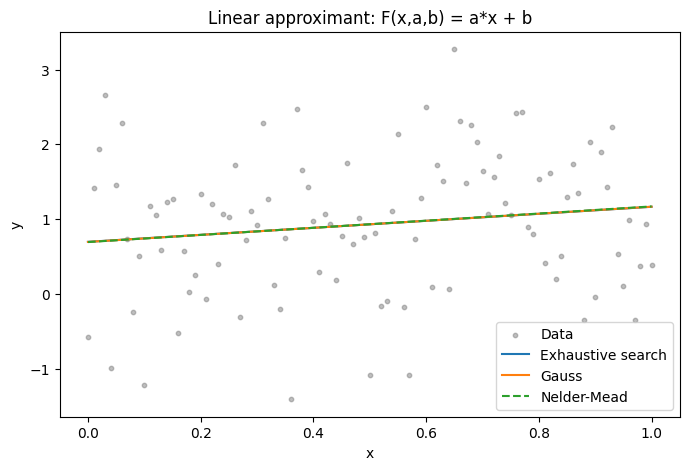

In [163]:
import matplotlib.pyplot as plt

x_plot = [k/1000 for k in range(1001)]
plt.figure(figsize=(8, 5))
plt.scatter(xs, ys, s=10, color="gray", alpha=0.5, label="Data")

plt.plot(x_plot, [linear_approximant(x, linear_a_me, linear_b_me) for x in x_plot], label="Exhaustive search")
plt.plot(x_plot, [linear_approximant(x, linear_a_g, linear_b_g) for x in x_plot], label="Gauss")
plt.plot(x_plot, [linear_approximant(x, linear_a_nd, linear_b_nd) for x in x_plot], label="Nelder-Mead", linestyle="--")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear approximant: F(x,a,b) = a*x + b")
plt.legend()
plt.show()

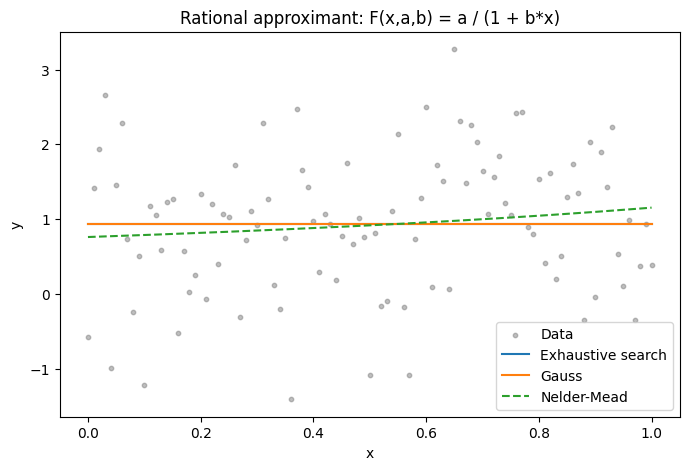

In [164]:
plt.figure(figsize=(8, 5))
plt.scatter(xs, ys, s=10, color="gray", alpha=0.5, label="Data")

plt.plot(x_plot, [rational_approximant(x, rational_a_me, rational_b_me) for x in x_plot], label="Exhaustive search")
plt.plot(x_plot, [rational_approximant(x, rational_a_g, rational_b_g) for x in x_plot], label="Gauss")
plt.plot(x_plot, [rational_approximant(x, rational_a_nd, rational_b_nd) for x in x_plot], label="Nelder-Mead", linestyle="--")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Rational approximant: F(x,a,b) = a / (1 + b*x)")
plt.legend()
plt.show()

For linear approximation, all methods yielded similar results, identifying comparable values ​​for parameters a, b, and D; however, there was a significant difference in the number of computations and iterations required: despite the similar outcomes, the multidimensional exhaustive search method demanded substantially more resources.  
  
Discrepancies were observed in the case of rational approximation: the exhaustive search and Gauss methods were constrained to the search range [0, 1] and both found a solution at the boundary of this range (b ≈ 0)—since the true minimum lay outside the interval—whereas the Nelder-Mead method was able to find the value because it was not restricted by the interval.  
  
Overall, the number of iterations and function evaluations for the Gauss and Nelder-Mead methods was orders of magnitude lower than for the exhaustive search, while the accuracy remained comparable (or, in the case of the rational model, even superior for Nelder-Mead).